# 📊 Análise de Dados — IEGM 2023 | Municípios do Estado do Ceará
---

## 🏛️ Contexto e Problemática

O **Índice de Efetividade da Gestão Municipal (IEGM)** é uma ferramenta de avaliação da qualidade da gestão pública idealizada pelo **Tribunal de Contas do Estado de São Paulo (TCESP)** em 2015, adotada posteriormente por outros Tribunais de Contas estaduais — incluindo o **Tribunal de Contas do Estado do Ceará (TCE-CE)**.

O IEGM avalia **sete dimensões** fundamentais da gestão municipal, cada uma representada por um índice específico:

| Índice | Área Avaliada |
|--------|---------------|
| **I-Amb** | Meio Ambiente |
| **I-Cidade** | Proteção das Cidades |
| **I-Educ** | Educação |
| **I-Fiscal** | Gestão Fiscal |
| **I-Gov TI** | Governança de Tecnologia da Informação |
| **I-Saúde** | Saúde |
| **I-Plan** | Planejamento |

A nota final de cada índice é classificada em **faixas de desempenho** que refletem o grau de efetividade das políticas públicas municipais:

| Faixa | Classificação |
|-------|---------------|
| **A** | Altamente efetiva |
| **B+** | Muito efetiva |
| **B** | Efetiva |
| **C+** | Em fase de adequação |
| **C** | Baixo nível de adequação |

---

## Objetivo da Análise

Com **184 municípios** no Estado do Ceará, surgem questões relevantes para gestores, pesquisadores e cidadãos:

- **Qual município teve a melhor nota em cada uma das sete áreas do IEGM?**
- **Quais foram as respostas enviadas por esse município que contribuíram para essa nota?**
- **Qual nota cada resposta recebeu**, permitindo entender o que fez a diferença no desempenho.

Esta análise busca responder essas perguntas de forma visual e objetiva, utilizando os dados do IEGM 2023 disponibilizados pelo TCE-CE.

---
> 📁 **Fonte dos dados:** TCECE — Tribunal de Contas do Estado do Ceará, ano de referência 2023.

In [ ]:
# ============================================================
# Importação das bibliotecas necessárias
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configurações de visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

## Carregamento dos Dados

Foram utilizadas três bases de dados fornecidas pelo TCE-CE referentes ao ano de 2023:

- **geral_iegm**: Notas e faixas consolidadas por município em cada área
- **respostas**: Respostas individuais de cada município por questão e área
- **calculo**: Detalhamento do cálculo das notas, rebaixamentos e faixas finais

In [ ]:
# ============================================================
# Carregamento das bases de dados
# ============================================================

# Base 1: Notas gerais por município
df_geral = pd.read_csv('geral_iegm_2023_TCECE_municipio.csv', sep=';', decimal=',', encoding='utf-16')

# Base 2: Respostas individuais — engine python para lidar com linhas inconsistentes
df_respostas = pd.read_csv(
    'respostas_iegm_2023_TCECE_completo_nota.csv',
    sep=';',
    decimal=',',
    encoding='utf-16',
    engine='python',
    on_bad_lines='skip'   # pula linhas com campos a mais
)

# Base 3: Cálculo detalhado das notas por área
df_calculo = pd.read_csv('calculo_iegm_2023_TCECE_completo.csv', sep=';', decimal=',', encoding='utf-16')

print("Bases carregadas com sucesso:")
print(f"\ndf_geral:     {df_geral.shape[0]} linhas | {df_geral.shape[1]} colunas")
print(f"df_respostas: {df_respostas.shape[0]} linhas | {df_respostas.shape[1]} colunas")
print(f"df_calculo:   {df_calculo.shape[0]} linhas | {df_calculo.shape[1]} colunas")

Bases carregadas com sucesso:

df_geral:     182 linhas | 22 colunas
df_respostas: 199102 linhas | 18 colunas
df_calculo:   1274 linhas | 15 colunas


## Exploração Inicial

Antes de qualquer análise, é importante entender a estrutura das bases de dados:
como estão organizadas, quais são os tipos de cada coluna e se há valores ausentes.

In [ ]:
# -----------------------------------------------------
# BASE GERAL
# -----------------------------------------------------
print("=" * 60)
print("BASE GERAL — Primeiras linhas")
print("=" * 60)
display(df_geral.head())

print("\n Tipos de dados e valores nulos:")
df_geral.info()

print("\n Estatísticas descritivas das notas percentuais:")
colunas_pct = [c for c in df_geral.columns if c.startswith('pct_')]
display(df_geral[colunas_pct].describe().T.rename(columns={
    'count': 'Qtd', 'mean': 'Média', 'std': 'Desvio Padrão',
    'min': 'Mín', '25%': 'Q1', '50%': 'Mediana', '75%': 'Q3', 'max': 'Máx'
}).round(4))


BASE GERAL — Primeiras linhas


,tribunal_id,tribunal,municipio_id,codigo_ibge,municipio,ano_ref,pct_iamb,pct_icidade,pct_ieduc,pct_ifiscal,pct_igov_ti,pct_isaude,pct_iplan,pct_iegm_municipio,ind_iamb,ind_icidade,ind_ieduc,ind_ifiscal,ind_igov_ti,ind_isaude,ind_iplan,ind_iegm_municipio
0,18,TCECE,10821,2300101,ABAIARA,2023,0.25,0.14,0.24,0.49,0.14,0.55,0.32,0.3590,C,C,C,C,C,C+,C,C
1,18,TCECE,10822,2300150,ACARAPE,2023,0.29,0.00,0.16,0.60,0.35,0.49,0.21,0.3385,C,C,C,B,C,C,C,C
2,18,TCECE,10823,2300200,ACARAÚ,2023,0.06,0.47,0.27,0.74,0.23,0.50,0.28,0.3990,C,C,C,B,C,C+,C,C
3,18,TCECE,10824,2300309,ACOPIARA,2023,0.57,0.40,0.20,0.49,0.20,0.45,0.24,0.3630,C+,C,C,C,C,C,C,C
4,18,TCECE,10825,2300408,AIUABA,2023,0.18,0.21,0.18,0.49,0.24,0.46,0.35,0.3365,C,C,C,C,C,C,C,C



 Tipos de dados e valores nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tribunal_id         182 non-null    int64  
 1   tribunal            182 non-null    object 
 2   municipio_id        182 non-null    int64  
 3   codigo_ibge         182 non-null    int64  
 4   municipio           182 non-null    object 
 5   ano_ref             182 non-null    int64  
 6   pct_iamb            182 non-null    float64
 7   pct_icidade         182 non-null    float64
 8   pct_ieduc           182 non-null    float64
 9   pct_ifiscal         182 non-null    float64
 10  pct_igov_ti         182 non-null    float64
 11  pct_isaude          182 non-null    float64
 12  pct_iplan           182 non-null    float64
 13  pct_iegm_municipio  182 non-null    float64
 14  ind_iamb            182 non-null    object 
 15  ind_icidade         182

,Qtd,Média,Desvio Padrão,Mín,Q1,Mediana,Q3,Máx
pct_iamb,182.0,0.2307,0.1810,0.0000,0.090,0.1900,0.3275,1.000
pct_icidade,182.0,0.2554,0.2016,0.0000,0.080,0.2300,0.3900,1.000
pct_ieduc,182.0,0.3532,0.0966,0.1000,0.290,0.3700,0.4200,0.560
pct_ifiscal,182.0,0.5327,0.1041,0.1800,0.490,0.4900,0.5900,0.980
pct_igov_ti,182.0,0.2998,0.1607,0.0800,0.190,0.2600,0.3700,1.000
pct_isaude,182.0,0.5499,0.0792,0.3000,0.490,0.5400,0.6000,0.930
pct_iplan,182.0,0.2980,0.1198,0.0200,0.240,0.2750,0.3400,0.900
pct_iegm_municipio,182.0,0.3976,0.0619,0.2775,0.361,0.3918,0.4238,0.778


In [ ]:
# -----------------------------------------------------
# BASE RESPOSTAS
# -----------------------------------------------------
print("\n" + "=" * 60)
print("BASE RESPOSTAS — Primeiras linhas")
print("=" * 60)
display(df_respostas.head())

print("\n Tipos de dados e valores nulos:")
df_respostas.info()

print("\n Valores nulos por coluna:")
nulos_respostas = df_respostas.isnull().sum()
nulos_respostas = nulos_respostas[nulos_respostas > 0]
if nulos_respostas.empty:
    print("Nenhum valor nulo encontrado.")
else:
    display(nulos_respostas.rename("Qtd Nulos"))

print(f"\n Indicadores presentes: {df_respostas['indicador'].unique()}")


BASE RESPOSTAS — Primeiras linhas


,tribunal_id,tribunal,codigo_ibge,municipio,indicador,questionario_id,nome_questionario,questionario_resposta_id,data_termino,questao_id,sequencia_bloco_repeticao,indice_questao,chave_questao,questao,chave_resposta,resposta,nota,ano_ref
0,18,TCECE,2300101,ABAIARA,i-Amb,42,I-Amb Nacional - 2024 [42],33670,01/07/2024,4815,1,001.,M05Q00900,A prefeitura possui alguma estrutura organizacional para tratar de assuntos ligados ao Meio Ambiente Municipal?,M05Q00900R00100,Sim,0.0,2023
1,18,TCECE,2300101,ABAIARA,i-Amb,42,I-Amb Nacional - 2024 [42],33670,01/07/2024,4816,1,001.001.,M05Q00910,A Prefeitura possui recursos humanos para operacionalização dos assuntos ligados ao Meio Ambiente?,M05Q00910R00100,Sim,5.0,2023
2,18,TCECE,2300101,ABAIARA,i-Amb,42,I-Amb Nacional - 2024 [42],33670,01/07/2024,4817,1,001.001.001.,M05Q00911R00100,Informe: Nº de efetivos:,NaN,1,0.0,2023
3,18,TCECE,2300101,ABAIARA,i-Amb,42,I-Amb Nacional - 2024 [42],33670,01/07/2024,4818,1,001.001.002.,M05Q00911R00200,Informe: Nº de comissionados:,NaN,1,0.0,2023
4,18,TCECE,2300101,ABAIARA,i-Amb,42,I-Amb Nacional - 2024 [42],33670,01/07/2024,4819,1,001.001.003.,M05Q00911R00300,Informe: Nº de terceirizados/contratados:,NaN,0,0.0,2023



 Tipos de dados e valores nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199102 entries, 0 to 199101
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   tribunal_id                199102 non-null  int64  
 1   tribunal                   199102 non-null  object 
 2   codigo_ibge                199102 non-null  int64  
 3   municipio                  199102 non-null  object 
 4   indicador                  199102 non-null  object 
 5   questionario_id            199102 non-null  int64  
 6   nome_questionario          199102 non-null  object 
 7   questionario_resposta_id   199102 non-null  int64  
 8   data_termino               199102 non-null  object 
 9   questao_id                 199102 non-null  int64  
 10  sequencia_bloco_repeticao  199102 non-null  int64  
 11  indice_questao             199102 non-null  object 
 12  chave_questao              199102 non-null  object 


,Qtd Nulos
chave_resposta,115579



 Indicadores presentes: ['i-Amb' 'i-Cidade' 'i-Educ' 'i-Fiscal' 'i-Gov TI' 'i-Plan' 'i-Saude']


In [ ]:
# -----------------------------------------------------
# BASE CÁLCULO
# -----------------------------------------------------
print("\n" + "=" * 60)
print("BASE CÁLCULO — Primeiras linhas")
print("=" * 60)
display(df_calculo.head())

print("\n Tipos de dados e valores nulos:")
df_calculo.info()

print("\n Valores nulos por coluna:")
nulos_calculo = df_calculo.isnull().sum()
nulos_calculo = nulos_calculo[nulos_calculo > 0]
if nulos_calculo.empty:
    print("Nenhum valor nulo encontrado.")
else:
    display(nulos_calculo.rename("Qtd Nulos"))

print("\n Distribuição por faixa de classificação:")
display(df_calculo.groupby(['indicador', 'faixa']).size().unstack(fill_value=0))


BASE CÁLCULO — Primeiras linhas


,tribunal_id,tribunal,codigo_ibge,municipio,indicador,quantidade_respostas,quantidade_respostas_pontuadas,nota_final,nota_ajustada_dentro_faixa,pct_indice_dentro_faixa,faixa,rebaixamentos,pct_indice_apos_analise_rebaixamento,faixa_apos_analise_rebaixamento,ano_ref
0,18,TCECE,2300101,ABAIARA,i-Amb,54,20,254.50,254.50,0.25,C,0,0.25,C,2023
1,18,TCECE,2300101,ABAIARA,i-Cidade,24,7,140.00,140.00,0.14,C,0,0.14,C,2023
2,18,TCECE,2300101,ABAIARA,i-Educ,208,64,241.65,241.65,0.24,C,2,0.24,C,2023
3,18,TCECE,2300101,ABAIARA,i-Fiscal,106,32,650.48,650.48,0.65,B,Rebaixa para faixa C,0.49,C,2023
4,18,TCECE,2300101,ABAIARA,i-Gov TI,26,14,140.00,140.00,0.14,C,0,0.14,C,2023



 Tipos de dados e valores nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1274 entries, 0 to 1273
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   tribunal_id                           1274 non-null   int64  
 1   tribunal                              1274 non-null   object 
 2   codigo_ibge                           1274 non-null   int64  
 3   municipio                             1274 non-null   object 
 4   indicador                             1274 non-null   object 
 5   quantidade_respostas                  1274 non-null   int64  
 6   quantidade_respostas_pontuadas        1274 non-null   int64  
 7   nota_final                            1274 non-null   float64
 8   nota_ajustada_dentro_faixa            1274 non-null   float64
 9   pct_indice_dentro_faixa               1274 non-null   float64
 10  faixa                                 1274 non-nul

faixa,A,B,B+,C,C+
indicador,,,,,
i-Amb,1,5,1,165,10
i-Cidade,1,7,3,162,9
i-Educ,0,0,0,168,14
i-Fiscal,1,78,14,38,51
i-Gov TI,2,9,1,161,9
i-Plan,1,5,2,173,1
i-Saude,1,57,1,40,83


---
## Análise 1 — Melhor Município em Cada Área do IEGM

Nesta primeira etapa, vamos identificar **qual município obteve a maior nota percentual**
em cada uma das sete áreas avaliadas pelo IEGM.

Para isso, utilizamos a base `geral_iegm_2023_TCECE_municipio.csv`, que consolida
as notas finais de todos os municípios cearenses.

As colunas de nota percentual são:
- `pct_ieduc` → Educação  
- `pct_isaude` → Saúde  
- `pct_iplan` → Planejamento  
- `pct_ifiscal` → Gestão Fiscal  
- `pct_iamb` → Meio Ambiente  
- `pct_icidade` → Proteção das Cidades  
- `pct_igov_ti` → Governança de TI

In [ ]:
# =====================================================
# MELHORES MUNICÍPIOS POR ÁREA — IEGM 2023
# =====================================================

areas = {
    'pct_iamb':     '🌿 Meio Ambiente',
    'pct_icidade':  '🏙️ Proteção das Cidades',
    'pct_ieduc':    '📚 Educação',
    'pct_ifiscal':  '💰 Gestão Fiscal',
    'pct_igov_ti':  '💻 Governança de TI',
    'pct_isaude':   '🏥 Saúde',
    'pct_iplan':    '📋 Planejamento',
}

resultados = []

for coluna, nome_area in areas.items():
    idx_max = df_geral[coluna].idxmax()
    linha = df_geral.loc[idx_max]
    col_ind = coluna.replace('pct_', 'ind_')
    faixa = linha[col_ind] if col_ind in df_geral.columns else '-'

    resultados.append({
        'Área': nome_area,
        'Município': linha['municipio'].title(),
        'Nota (%)': round(linha[coluna] * 100, 2) if linha[coluna] <= 1 else round(linha[coluna], 2),
        'Faixa': faixa
    })

df_melhores = pd.DataFrame(resultados)

print("=" * 60)
print("MELHORES MUNICÍPIOS POR ÁREA — IEGM 2023 | CEARÁ")
print("=" * 60)
display(df_melhores)

MELHORES MUNICÍPIOS POR ÁREA — IEGM 2023 | CEARÁ


,Área,Município,Nota (%),Faixa
0,🌿 Meio Ambiente,Sobral,100.0,A
1,🏙️ Proteção das Cidades,Sobral,100.0,A
2,📚 Educação,Groaíras,56.0,C+
3,💰 Gestão Fiscal,Sobral,98.0,A
4,💻 Governança de TI,Sobral,100.0,A
5,🏥 Saúde,Sobral,93.0,A
6,📋 Planejamento,Caucaia,90.0,A


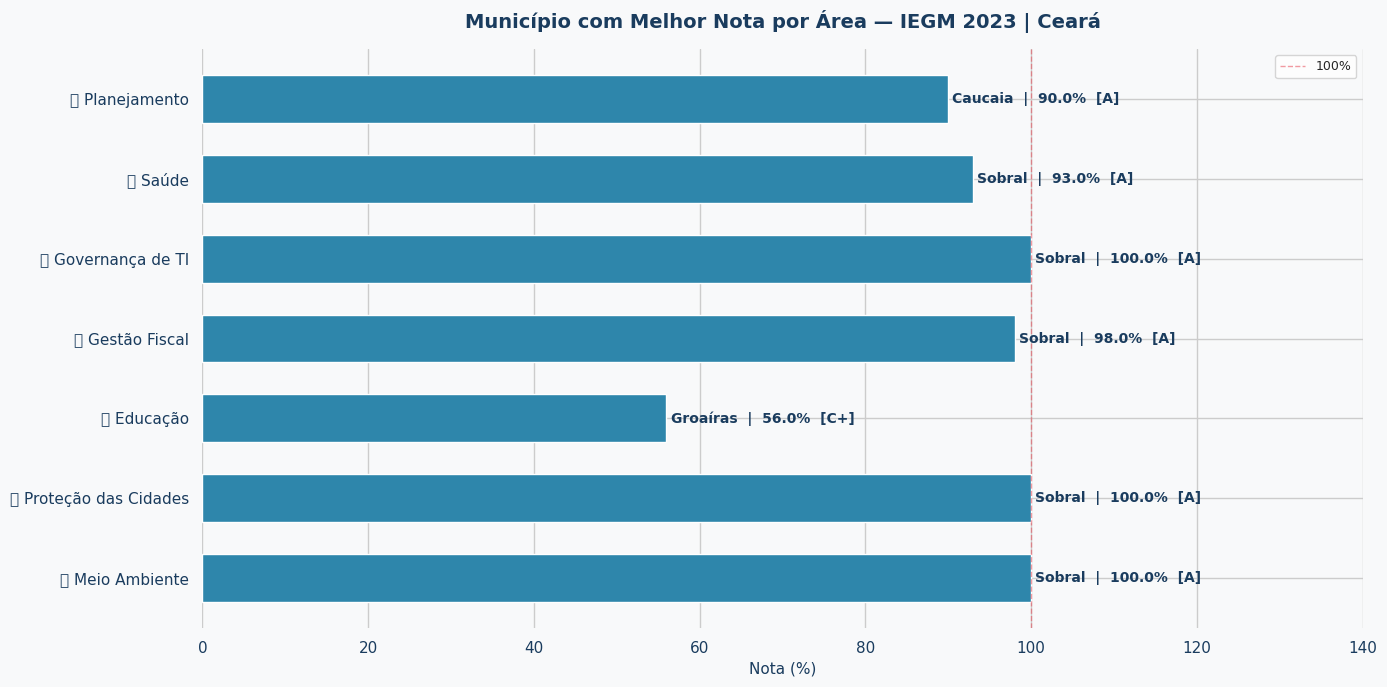

Gráfico salvo como 'melhores_por_area.png'


In [ ]:
# =====================================================
# VISUALIZAÇÃO — MELHORES NOTAS POR ÁREA
# =====================================================

# PALETA DE CORES
CORES = {
    'fundo':      '#F8F9FA',
    'principal':  '#1A3C5E',
    'destaque':   '#2E86AB',
    'negativo':   '#E63946',
}

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(CORES['fundo'])
ax.set_facecolor(CORES['fundo'])

barras = ax.barh(
    df_melhores['Área'],
    df_melhores['Nota (%)'],
    color=CORES['destaque'],
    edgecolor='white',
    height=0.6
)

for bar, row in zip(barras, df_melhores.itertuples()):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{row.Município}  |  {row._3:.1f}%  [{row.Faixa}]",
        va='center', ha='left',
        fontsize=10, fontweight='bold', color=CORES['principal']
    )

ax.set_xlim(0, 140)
ax.set_xlabel('Nota (%)', fontsize=11, color=CORES['principal'])
ax.set_title('Município com Melhor Nota por Área — IEGM 2023 | Ceará',
             fontsize=14, fontweight='bold', pad=15, color=CORES['principal'])
ax.axvline(100, color=CORES['negativo'], linestyle='--', linewidth=1, alpha=0.5, label='100%')
ax.tick_params(colors=CORES['principal'])
ax.legend(fontsize=9)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('melhores_por_area.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo como 'melhores_por_area.png'")